# Machine Learning Lab 04
## K-Nearest Neighbor (KNN) Classification

### Objective
This lab demonstrates how to use the K-Nearest Neighbor (KNN) algorithm to classify Heart Disease data.

### Dataset
- Heart Disease Dataset
- Target: HeartDisease


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset

Load the dataset into a Pandas DataFrame.

In [31]:
df = pd.read_csv("dataset.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Explore Dataset

Check the structure and basic information of the dataset.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [33]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [34]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

## Data Visualization

Display the distribution of Heart Disease classes.

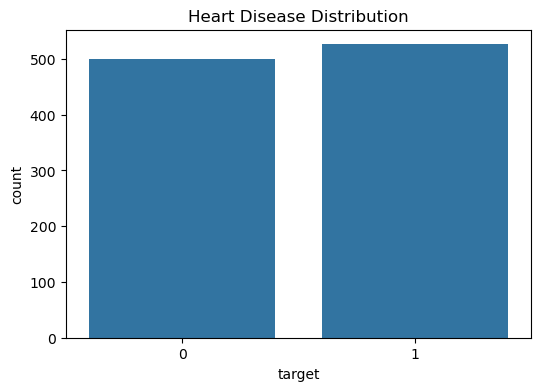

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target")
plt.title("Heart Disease Distribution")
plt.show()

## Feature Selection

Separate the input features (X) and target variable (y).


In [36]:
X = df.drop("target", axis=1)
y = df["target"]

## Split Dataset

Split the dataset into training and testing sets.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Standardize Features

Scale the features using StandardScaler.

In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train KNN Models

Train KNN models with different k values (3, 5, and 7).

In [39]:
k_values = [3,5,7]

results = []

for k in k_values:
    
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append([k, accuracy])
    
    print(f"k = {k}")
    print(f"Accuracy = {accuracy:.4f}")
    print("-"*30)

k = 3
Accuracy = 0.9366
------------------------------
k = 5
Accuracy = 0.8341
------------------------------
k = 7
Accuracy = 0.8244
------------------------------


## Compare Accuracy

Compare the accuracy of each k value.

In [40]:
results_df = pd.DataFrame(results, columns=["k","Accuracy"])

results_df

,k,Accuracy
0,3,0.936585
1,5,0.834146
2,7,0.824390


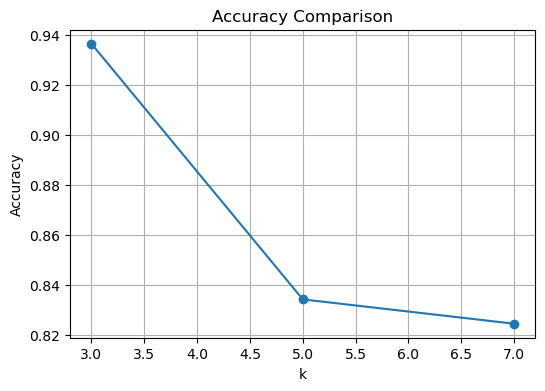

In [41]:
plt.figure(figsize=(6,4))

plt.plot(results_df["k"], results_df["Accuracy"], marker="o")

plt.xlabel("k")

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.grid(True)

plt.show()

## Best K Value

Find the best k based on the highest accuracy.

In [42]:
best = results_df.loc[results_df["Accuracy"].idxmax()]

print("Best k =", best["k"])

print("Accuracy =", best["Accuracy"])

Best k = 3.0
Accuracy = 0.9365853658536586


## Confusion Matrix

Evaluate the best KNN model using a confusion matrix.

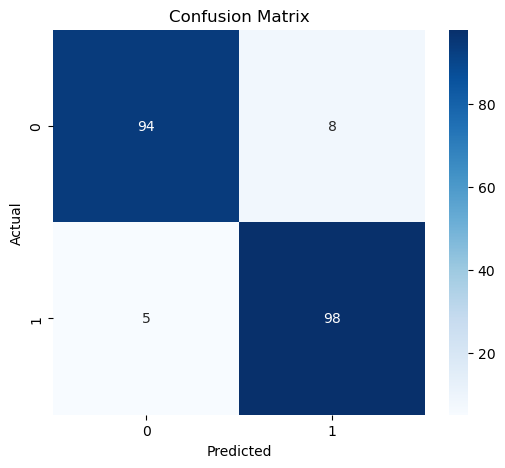

In [43]:
best_model = KNeighborsClassifier(n_neighbors=int(best["k"]))

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Classification Report

Display Precision, Recall, F1-score, and Accuracy.

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94       102
           1       0.92      0.95      0.94       103

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205



# Conclusion

- The KNN algorithm was trained using three different k values.
- The model with the highest accuracy was selected.
- Feature standardization improved KNN performance.
- KNN is simple and effective for Heart Disease classification.